# Visualizing MESA reactions

In [1]:
import pynucastro as pyna
import mesa_reader as mr

In [2]:
import re

## Read in the MESA model

In [3]:
model = mr.MesaData("profile2.data")

We want to parse the nuclei used in the MESA run from the header using a regex

In [4]:
species_re = re.compile(r"log_([a-z]+[\d]+)")

In [5]:
nuclei = []
for field in model.bulk_names:
    if g := species_re.match(field):
        nuclei.append(g.group(1))

Now create a dictionary keyed by MESA zone that holds a tuple, (density, temperature, composition),
where compostion is a pynucastro `Composition` object.

In [6]:
mesa_zones = {}

for i in range(model.header_data["num_zones"]):
    rho = 10.0**model.bulk_data[i]["logRho"]
    T = 10.0**model.bulk_data[i]["logT"]
    comp = pyna.Composition(nuclei)
    for n in nuclei:
        val = 10.0**model.bulk_data[i][f"log_{n}"]
        comp[pyna.Nucleus(n)] = val
    mesa_zones[i] = (rho, T, comp)

## Create the network using the same species as the MESA model

By default, `network_helper` will find all the rates connecting the nuclei, some of which were likely not used in the MESA simulation.

In [7]:
net = pyna.network_helper(nuclei)

In [8]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 15
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  total number of rates: 38

  rates explicitly connecting nuclei: 38
  hidden rates: 0

  reaclib rates: 12
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 14
  approximate rates: 0
  derived rates: 12
  modified rates: 0
  custom rates: 0


We can see the structure of the network

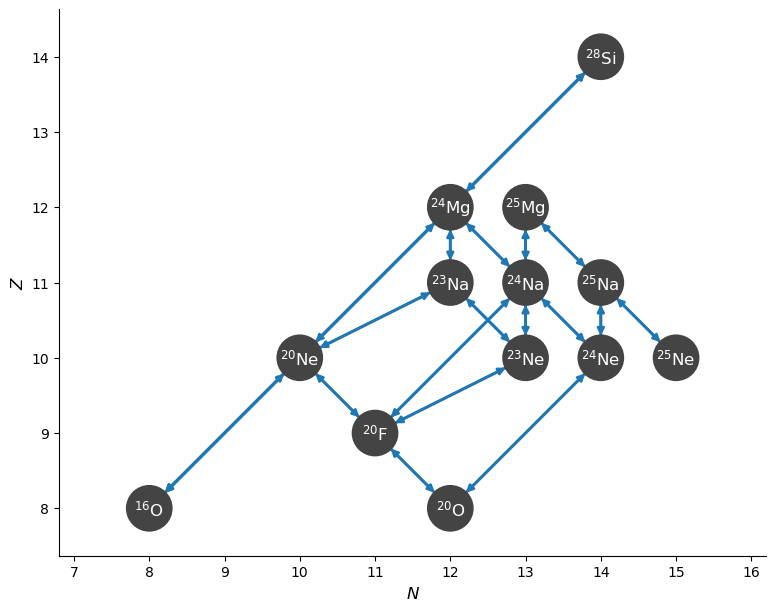

In [9]:
fig = net.plot()

and the rates and their sources

In [10]:
net.rates[0].source

{'Label': 'co10',
 'Author': 'Constantini, H. et al',
 'Title': '16O(&alpha;,&gamma;)20Ne S factor: Measurements and R-matrix analysis',
 'Publisher': 'PRC 82, 035802',
 'Year': '2010',
 'URL': 'https://doi.org/10.1103/PhysRevC.82.035802'}

In [11]:
for r in net.rates:
    print(f"{r!s:30} : {r.source['Label']}")

O16 + He4 ⟶ Ne20 + 𝛾           : co10
O20 + He4 ⟶ Ne24 + 𝛾           : rpsm
F20 + He4 ⟶ Na24 + 𝛾           : rpsm
Ne20 + He4 ⟶ Mg24 + 𝛾          : il10
Ne23 + p ⟶ Na24 + 𝛾            : rath
Ne24 + p ⟶ Na25 + 𝛾            : rath
Na23 + p ⟶ Mg24 + 𝛾            : il10
Na24 + p ⟶ Mg25 + 𝛾            : rath
Mg24 + He4 ⟶ Si28 + 𝛾          : st08
O16 + O16 ⟶ He4 + Si28         : cf88
F20 + He4 ⟶ p + Ne23           : rpsm
Na23 + p ⟶ He4 + Ne20          : il10
Ne20 ⟶ He4 + O16               : co10
Ne24 ⟶ He4 + O20               : rpsm
Na24 ⟶ p + Ne23                : rath
Na24 ⟶ He4 + F20               : rpsm
Na25 ⟶ p + Ne24                : rath
Mg24 ⟶ p + Na23                : il10
Mg24 ⟶ He4 + Ne20              : il10
Mg25 ⟶ p + Na24                : rath
Si28 ⟶ He4 + Mg24              : st08
Ne20 + He4 ⟶ p + Na23          : il10
Ne23 + p ⟶ He4 + F20           : rpsm
Si28 + He4 ⟶ O16 + O16         : cf88
F20 ⟶ Ne20 + e⁻ + 𝜈            : suzuki
F20 + e⁻ ⟶ O20 + 𝜈             : suzuki
Ne20 + e

The Suzuki rates are not valid for $\rho Y_e < 10^7~\mathrm{g~cm^{-3}}$, so let's find the model index that corresponds to

In [12]:
i_cutoff = min(i for i in range(len(mesa_zones)) if mesa_zones[i][0] * mesa_zones[i][-1].ye > 1.e7)

## A network plot

Here's a function that takes a zone index and makes a plot

In [13]:
def _make_plot(i_zone, curved_edges=False):
    rho, T, comp = mesa_zones[i_zone]
    fig = net.plot(rho=rho, T=T, comp=comp,
                   use_net_rate=True, curved_edges=curved_edges,
                   ydot_cutoff_value=1.e-30,
                   show_small_ydot=True,               
                   color_nodes_by_abundance=True)
    fig.text(0.1, 0.9, rf"T = {T:6.3g} K, $\rho$ = {rho:6.3g} g/cm$^3$", transform=fig.transFigure)
    fig.text(0.1, 0.925, f"zone = {i_zone}", transform=fig.transFigure)

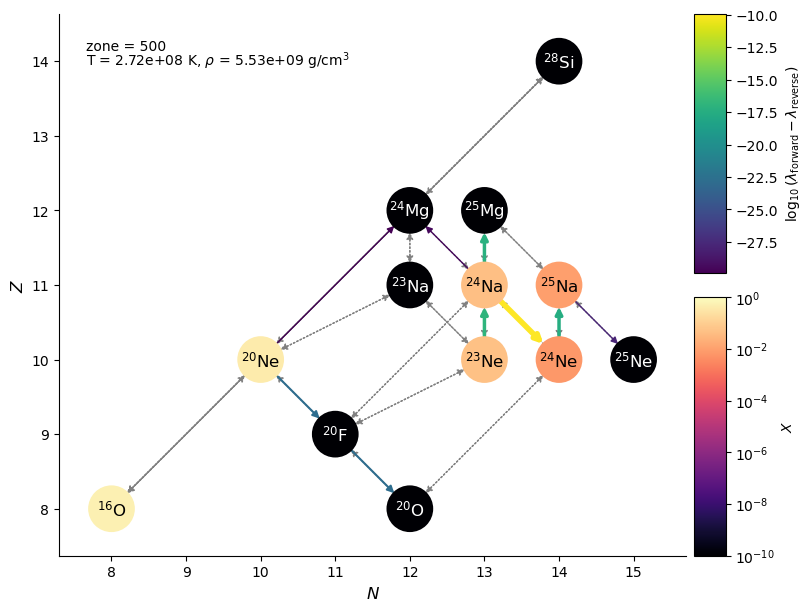

In [14]:
_make_plot(500)

## Interactive plot

We can make the plot interactive by using `ipywidgets`

In [15]:
from ipywidgets import interact

In [16]:
interact(_make_plot, i_zone=(i_cutoff, len(mesa_zones)-1, 1), curved_edges=False)

interactive(children=(IntSlider(value=541, description='i_zone', max=785, min=298), Checkbox(value=False, desc…

<function __main__._make_plot(i_zone, curved_edges=False)>